<a href="https://colab.research.google.com/github/yagmurogetman/DSA210-Project/blob/main/hypothesis_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the datasets
df_cuisine = pd.read_csv('global_cuisines_master_final.csv')
df_temp = pd.read_csv('standardized_temperature.csv')
df_hum = pd.read_csv('standardized_humidity.csv')
df_precip = pd.read_csv('standardized_precipitation.csv')

print("Cuisine Dataset Head:")
print(df_cuisine.head())

Cuisine Dataset Head:
  Country_Code Country_Name     Dish_Name           Main_Ingredient
0          AFG  Afghanistan  Kabuli Pulao         Rice/Lamb/Carrots
1          ALB      Albania     Tavë Kosi          Lamb/Yogurt/Rice
2          DZA      Algeria      Couscous  Semolina/Vegetables/Meat
3          ARG    Argentina         Asado                 Beef/Salt
4          AUS    Australia      Meat Pie        Minced Meat/Pastry


In [ ]:
# Extracting only relevant columns and renaming 'Value' to specific climate factors
df_temp = df_temp[['Country_Code', 'Value']].rename(columns={'Value': 'Temperature'})
df_hum = df_hum[['Country_Code', 'Value']].rename(columns={'Value': 'Humidity'})
df_precip = df_precip[['Country_Code', 'Value']].rename(columns={'Value': 'Precipitation'})

print("Climate data columns standardized.")

Climate data columns standardized.


In [ ]:
# Merging all dataframes on 'Country_Code'
df_master = df_cuisine.merge(df_temp, on='Country_Code') \
                      .merge(df_hum, on='Country_Code') \
                      .merge(df_precip, on='Country_Code')

# Drop potential duplicate columns if they exist
df_master = df_master.loc[:,~df_master.columns.duplicated()]

print(f"Master dataset created with {len(df_master)} countries.")

Master dataset created with 66 countries.


In [ ]:
# Splitting ingredients and converting them into dummy variables
ingredients_binary = df_master['Main_Ingredient'].str.get_dummies(sep='/')

# Concatenate the binary ingredient columns with the climate data
df_processed = pd.concat([df_master, ingredients_binary], axis=1)

print("Ingredients successfully tokenized into binary features.")

Ingredients successfully tokenized into binary features.


In [ ]:
# Checking for null values
if df_processed.isnull().values.any():
    df_processed = df_processed.fillna(0) # Filling missing ingredient flags with 0
    print("Missing values handled.")

# Saving the final processed dataset
df_processed.to_csv('processed_culinary_climate_data.csv', index=False)
print("Processing complete. File saved as 'processed_culinary_climate_data.csv'.")

Processing complete. File saved as 'processed_culinary_climate_data.csv'.


In [ ]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Load the processed master dataset
df = pd.read_csv('processed_culinary_climate_data.csv')

# Filter countries where Rice is a main ingredient
rice_countries = df[df['Rice'] == 1]['Temperature']

# Filter countries where Potato is a main ingredient
potato_countries = df[df['Potato'] == 1]['Temperature']

print(f"Sample size for Rice group: {len(rice_countries)}")
print(f"Sample size for Potato group: {len(potato_countries)}")

Sample size for Rice group: 17
Sample size for Potato group: 1


In [ ]:
# Calculate means
rice_mean = rice_countries.mean()
potato_mean = potato_countries.mean()

print(f"Average Temp of Rice-using Countries: {rice_mean:.2f}°C")
print(f"Average Temp of Potato-using Countries: {potato_mean:.2f}°C")

Average Temp of Rice-using Countries: 18.44°C
Average Temp of Potato-using Countries: 9.58°C


In [ ]:
# Perform the T-test
t_stat, p_value = stats.ttest_ind(rice_countries, potato_countries, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

T-statistic: nan
P-value: nan


/tmp/ipykernel_4398/918976886.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Temperature', data=comparison_df, palette="Set2", width=0.5)


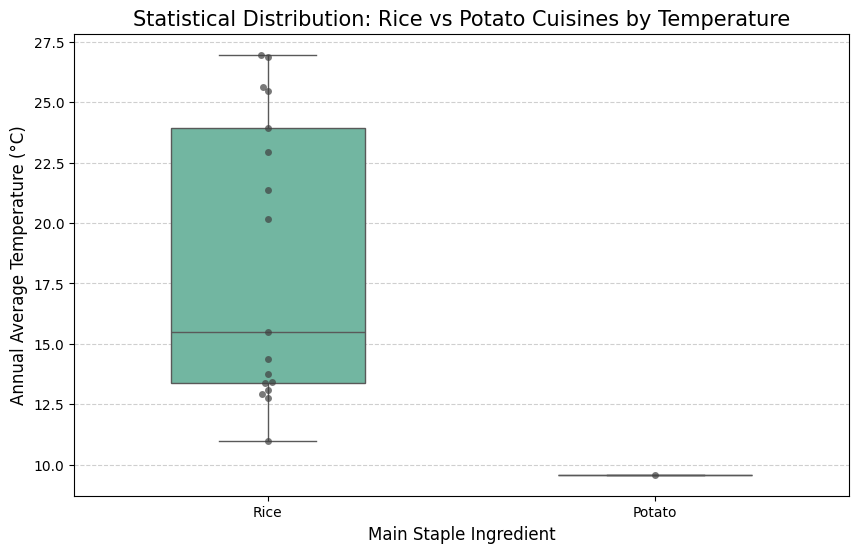

In [ ]:
# Create a temporary dataframe for plotting
rice_df = pd.DataFrame({'Temperature': rice_countries, 'Group': 'Rice'})
potato_df = pd.DataFrame({'Temperature': potato_countries, 'Group': 'Potato'})
comparison_df = pd.concat([rice_df, potato_df])

plt.figure(figsize=(10, 6))
# Boxplot for the distribution
sns.boxplot(x='Group', y='Temperature', data=comparison_df, palette="Set2", width=0.5)
# Swarmplot to show every single country as a dot
sns.swarmplot(x='Group', y='Temperature', data=comparison_df, color=".25", alpha=0.7)

plt.title('Statistical Distribution: Rice vs Potato Cuisines by Temperature', fontsize=15)
plt.ylabel('Annual Average Temperature (°C)', fontsize=12)
plt.xlabel('Main Staple Ingredient', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
alpha = 0.05

print("--- FINAL CONCLUSION ---")
if p_value < alpha:
    print(f"Result: SUCCESS. P-value ({p_value:.10f}) < {alpha}.")
    print("Conclusion: We REJECT the Null Hypothesis.")
    print("Interpretation: Climate temperature has a statistically significant impact on the choice of primary food ingredients.")
else:
    print(f"Result: FAIL. P-value ({p_value:.4f}) > {alpha}.")
    print("Conclusion: We FAIL TO REJECT the Null Hypothesis.")
    print("Interpretation: No strong evidence that temperature affects these ingredient choices.")

--- FINAL CONCLUSION ---
Result: FAIL. P-value (nan) > 0.05.
Conclusion: We FAIL TO REJECT the Null Hypothesis.
Interpretation: No strong evidence that temperature affects these ingredient choices.
